# EN3150 Assignment 03: Resource-Constrained CNN for Edge Image Classification

**Group Members:**
- [Student 1 Name] - [Index No]
- [Student 2 Name] - [Index No]
- [Student 3 Name] - [Index No]
- [Student 4 Name] - [Index No]

## 1. Introduction & Data Preparation

For this assignment, we are tasked with building a lightweight image classifier designed for embedded or low-resource devices (e.g., edge nodes, microcontrollers).

We have selected the **TF Flowers dataset**, which contains images of 5 different flower classes.

**Preprocessing & Downscaling:**
As per the assignment guidelines, to emulate a low-resource sensor environment, we explicitly **downscale the original images to a resolution of 64x64 pixels** during the loading process. This constraint is critical for testing our lightweight CNN architectures.

**Data Split Strategy:**
The dataset is split into three subsets:
- **Training Set (70%):** Used for learning the features and updating model weights.
- **Validation Set (15%):** Used for hyperparameter tuning and preventing overfitting.
- **Testing Set (15%):** Held out completely for an unbiased final evaluation.

TensorFlow Version: 2.20.0
Loading and downscaling images to 64x64...
Found 3670 files belonging to 5 classes.
Using 2569 files for training.
Found 3670 files belonging to 5 classes.
Using 1101 files for validation.

Classes found: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Training batches: 81
Validation batches: 17
Testing batches: 18


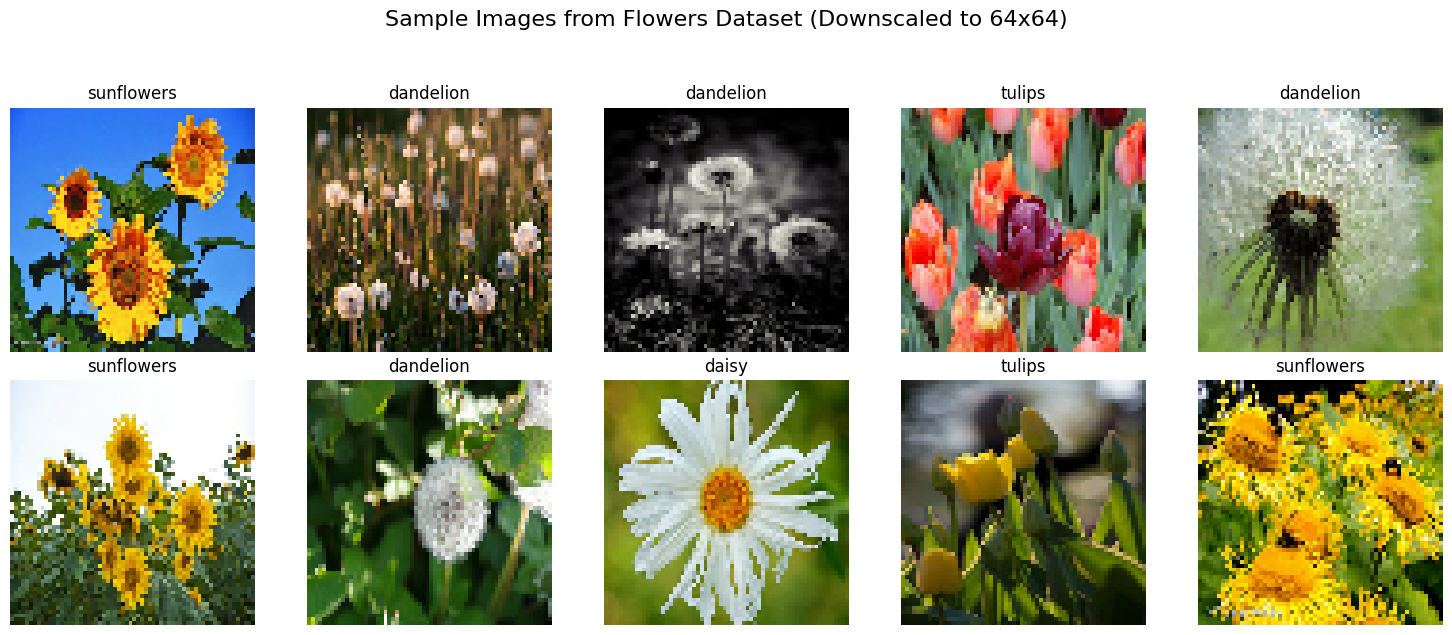

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pathlib
import os

# Set random seeds for reproducibility
tf.keras.utils.set_random_seed(42)

print("TensorFlow Version:", tf.__version__)

# 1. Download and Load the Dataset (TF Flowers)
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir_path = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)

# Fix for the "1 class" issue: Move one folder level deeper if extracted incorrectly
subdirs = [os.path.join(data_dir_path, d) for d in os.listdir(data_dir_path) if os.path.isdir(os.path.join(data_dir_path, d))]
if len(subdirs) == 1:
    data_dir_path = subdirs[0]

data_dir = pathlib.Path(data_dir_path)

# 2. Emulate low-resource sensor environment by downscaling to 64x64
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

print("Loading and downscaling images to 64x64...")

# Load 70% as Training Data
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.30, # Reserve 30% for Val/Test
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# [FIX]: Save class names BEFORE we modify (map) the dataset
class_names = train_dataset.class_names

# Load 30% as Validation Data
val_test_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.30,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Split the 30% into 15% Validation and 15% Test
val_test_batches = tf.data.experimental.cardinality(val_test_dataset)
val_batches = val_test_batches // 2

val_dataset = val_test_dataset.take(val_batches)
test_dataset = val_test_dataset.skip(val_batches)

print(f"\nClasses found: {class_names}")
print(f"Training batches: {tf.data.experimental.cardinality(train_dataset)}")
print(f"Validation batches: {tf.data.experimental.cardinality(val_dataset)}")
print(f"Testing batches: {tf.data.experimental.cardinality(test_dataset)}")

# 3. Preprocessing (Normalization)
def preprocess_image(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Apply normalization
train_dataset = train_dataset.map(preprocess_image).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.map(preprocess_image).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.map(preprocess_image).prefetch(tf.data.AUTOTUNE)

# 4. Visualize some samples
plt.figure(figsize=(15, 6))
# Using the class_names we saved earlier
for images, labels in train_dataset.take(1):
    for i in range(10):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.suptitle("Sample Images from Flowers Dataset (Downscaled to 64x64)", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

## 2. Custom Architecture Design

In this section, we design two distinct Convolutional Neural Networks (CNNs). Both models use **ReLU (Rectified Linear Unit)** activation functions.

**Hardware-aware Justification for ReLU:**
For edge devices and microcontrollers, avoiding computationally expensive exponential functions (like those found in Sigmoid or Tanh activations) is critical. ReLU simply outputs `max(0, x)`, which is executed as a fast bitwise operation on hardware. This significantly saves battery life and minimizes CPU/NPU cycles.

### 2.1 Model A: Standard CNN
This architecture interleaves standard 2D convolutions (`Conv2D`) and max-pooling layers. It relies on standard multiply-accumulate (MAC) operations which are dense and parameter-heavy. We use a `Flatten` layer followed by dense classification layers.

In [5]:
from tensorflow.keras import layers, models

def build_model_a(input_shape=(64, 64, 3), num_classes=5):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name="Model_A_Standard_CNN")
    return model

model_a = build_model_a()

print("="*60)
print("MODEL A: STANDARD CNN SUMMARY")
print("="*60)
model_a.summary()

MODEL A: STANDARD CNN SUMMARY


Model: "Model_A_Standard_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,597 (4.36 MB)

 Trainable params: 1,142,597 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

### 2.2 Model B: Lightweight CNN (Edge-Optimized)
To drastically reduce MAC operations and memory footprint, we replace standard convolutions with **Depthwise Separable Convolutions** (`SeparableConv2D`).

A standard convolution performs spatial and channel-wise computations simultaneously. A Depthwise Separable Convolution splits this into two efficient steps:
1. **Depthwise Convolution:** Applies a single spatial filter to each input channel independently.
2. **Pointwise Convolution (1x1):** Mixes the resulting output channels.

Furthermore, we replace the parameter-heavy `Flatten` layer with a `GlobalAveragePooling2D` layer. **The primary goal here is to keep the total trainable parameters strictly below the 100,000 parameter limit** required for edge deployments.

In [6]:
def build_model_b(input_shape=(64, 64, 3), num_classes=5):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Using SeparableConv2D to drastically reduce parameters
        layers.SeparableConv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.SeparableConv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.SeparableConv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.SeparableConv2D(256, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # GlobalAveragePooling2D is much more parameter-efficient than Flatten
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name="Model_B_Lightweight_CNN")
    return model

model_b = build_model_b()

print("="*60)
print("MODEL B: LIGHTWEIGHT CNN SUMMARY")
print("="*60)
model_b.summary()

MODEL B: LIGHTWEIGHT CNN SUMMARY


Model: "Model_B_Lightweight_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv2d                │ (None, 64, 64, 32)     │           155 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 32, 32, 64)     │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 16, 16, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 8, 8, 256)      │        34,176 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,168 (309.25 KB)

 Trainable params: 79,168 (309.25 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Optimizer Selection & Tuning

For our primary model training, we have selected the **Adam (Adaptive Moment Estimation) optimizer** with a standard **learning rate of 0.001**.

**Why Adam?**
Adam dynamically adapts the learning rate for each individual parameter. This leads to faster, more stable, and more reliable convergence than standard SGD, especially on complex image classification tasks.

### Comparing Optimizers
To empirically justify this choice, we will test our Lightweight CNN (Model B) across 8 epochs using three different optimizers:
1. **Standard SGD:** Updates weights strictly based on the current gradient. It is often slow and can easily get stuck in shallow local minima.
2. **SGD with Momentum (0.9):** Adds a fraction of the previous update to the current one.
   * **Impact of Momentum:** It builds up "velocity" in consistent directions, dampening oscillations and accelerating convergence.
3. **Adam:** Uses both first and second-order moments of the gradients, usually providing the fastest initial convergence.

In [7]:
# We will train Model B with 3 different optimizers for 8 epochs
# to practically compare their convergence speeds and stability.

EPOCHS_TUNE = 8
learning_rate = 0.001

optimizers_to_test = {
    'SGD': tf.keras.optimizers.SGD(learning_rate=learning_rate),
    'SGD_Momentum': tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9),
    'Adam': tf.keras.optimizers.Adam(learning_rate=learning_rate)
}

history_dict = {}

print("Starting Optimizer Comparison on Model B...\n")

for opt_name, opt in optimizers_to_test.items():
    print(f"--- Training with {opt_name} ---")

    # Clone Model B to reset weights for a fair comparison
    # (This creates a fresh, untrained copy of the model)
    temp_model = tf.keras.models.clone_model(model_b)
    temp_model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train for 8 epochs
    history = temp_model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS_TUNE,
        verbose=1
    )
    history_dict[opt_name] = history.history
    print("\n")

Starting Optimizer Comparison on Model B...

--- Training with SGD ---
Epoch 1/8
81/81 ━━━━━━━━━━━━━━━━━━━━ 20s 132ms/step - accuracy: 0.2343 - loss: 1.6093 - val_accuracy: 0.2390 - val_loss: 1.6092
Epoch 2/8
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.2429 - loss: 1.6089 - val_accuracy: 0.2500 - val_loss: 1.6086
Epoch 3/8
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.2429 - loss: 1.6084 - val_accuracy: 0.2574 - val_loss: 1.6082
Epoch 4/8
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.2429 - loss: 1.6080 - val_accuracy: 0.2390 - val_loss: 1.6082
Epoch 5/8
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.2429 - loss: 1.6076 - val_accuracy: 0.2335 - val_loss: 1.6082
Epoch 6/8
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.2429 - loss: 1.6073 - val_accuracy: 0.2463 - val_loss: 1.6072
Epoch 7/8
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.2429 - loss: 1.6069 - val_accuracy: 0.2316 - val_loss: 1.6079
Epoch 8/8
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/

### 3.1 Visualizing Convergence and the Impact of Momentum

The following graphs plot the validation loss and validation accuracy for each optimizer over the 8 epochs.

**Expected Observations:**
- **Standard SGD** typically shows a very slow, gradual improvement.
- **SGD with Momentum** should demonstrate significantly faster convergence compared to standard SGD. This directly visualizes the positive impact of the momentum parameter, as it helps the optimizer push through plateaus and accelerates learning.
- **Adam** generally outperforms both, reaching a higher accuracy and lower loss in the same number of epochs, which justifies our selection.

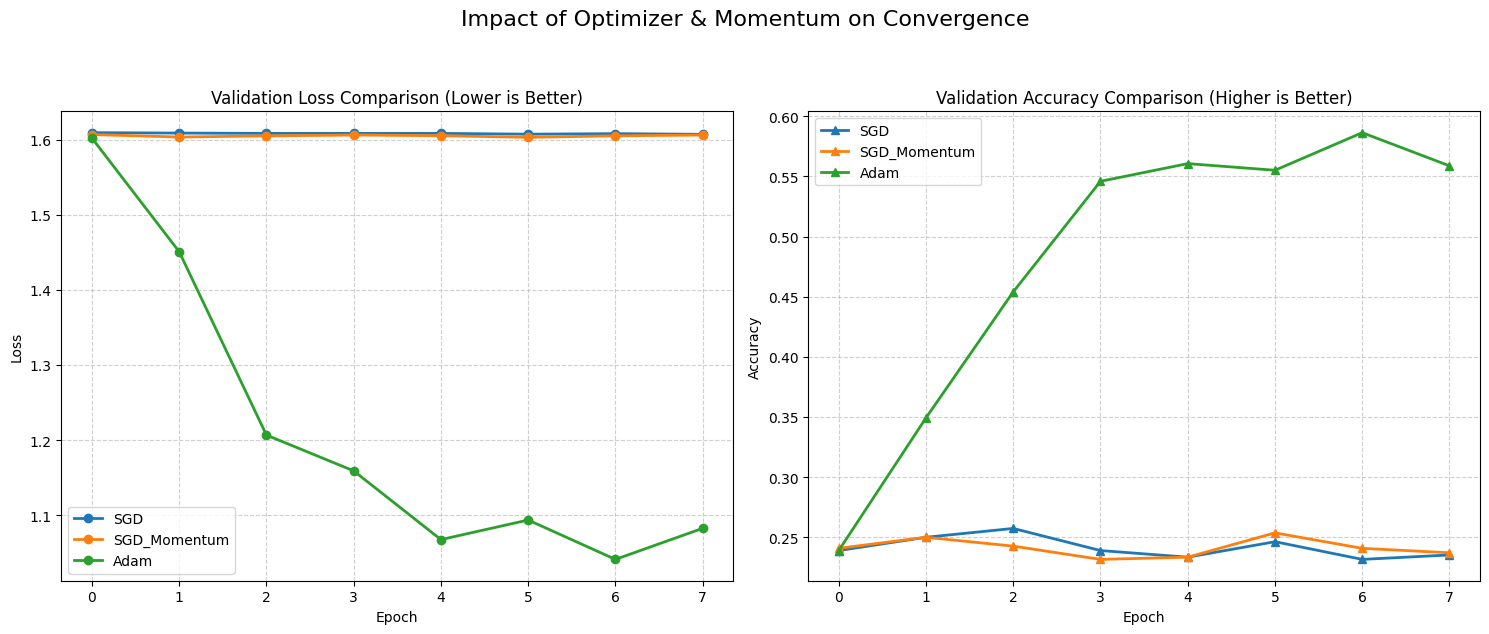

In [8]:
# Plotting the comparison
plt.figure(figsize=(15, 6))

# Validation Loss Plot
plt.subplot(1, 2, 1)
for opt_name in optimizers_to_test.keys():
    plt.plot(history_dict[opt_name]['val_loss'], label=f'{opt_name}', linewidth=2, marker='o')
plt.title('Validation Loss Comparison (Lower is Better)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Validation Accuracy Plot
plt.subplot(1, 2, 2)
for opt_name in optimizers_to_test.keys():
    plt.plot(history_dict[opt_name]['val_accuracy'], label=f'{opt_name}', linewidth=2, marker='^')
plt.title('Validation Accuracy Comparison (Higher is Better)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.suptitle("Impact of Optimizer & Momentum on Convergence", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

## 4. Custom Model Training & Evaluation

Having established **Adam** as our optimal optimizer, we will now perform the full training for both **Model A (Standard CNN)** and **Model B (Lightweight CNN)**.

As per the requirements, both models will be trained for **20 epochs**. During this process, we will track the average training time per epoch and save the final models to evaluate their memory footprint (size on disk in KB).

In [9]:
import time
import os

EPOCHS = 20
optimizer_a = tf.keras.optimizers.Adam(learning_rate=0.001)
optimizer_b = tf.keras.optimizers.Adam(learning_rate=0.001)

model_a.compile(optimizer=optimizer_a, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_b.compile(optimizer=optimizer_b, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("="*50)
print("TRAINING MODEL A (STANDARD CNN)")
print("="*50)
start_time_a = time.time()
history_a = model_a.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS)
end_time_a = time.time()
time_per_epoch_a = (end_time_a - start_time_a) / EPOCHS

print("\n" + "="*50)
print("TRAINING MODEL B (LIGHTWEIGHT CNN)")
print("="*50)
start_time_b = time.time()
history_b = model_b.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS)
end_time_b = time.time()
time_per_epoch_b = (end_time_b - start_time_b) / EPOCHS

# Save models to calculate disk size
model_a.save('model_a.h5')
model_b.save('model_b.h5')

size_a_kb = os.path.getsize('model_a.h5') / 1024
size_b_kb = os.path.getsize('model_b.h5') / 1024

print("\n" + "="*50)
print("TRAINING SUMMARY")
print("="*50)
print(f"Model A - Avg Time/Epoch: {time_per_epoch_a:.2f} seconds | Disk Size: {size_a_kb:.2f} KB")
print(f"Model B - Avg Time/Epoch: {time_per_epoch_b:.2f} seconds | Disk Size: {size_b_kb:.2f} KB")

TRAINING MODEL A (STANDARD CNN)
Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - accuracy: 0.4095 - loss: 1.3497 - val_accuracy: 0.5772 - val_loss: 1.0818
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.5804 - loss: 1.0347 - val_accuracy: 0.6213 - val_loss: 0.9514
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.6407 - loss: 0.9094 - val_accuracy: 0.6434 - val_loss: 0.9049
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.7034 - loss: 0.7752 - val_accuracy: 0.6746 - val_loss: 0.8985
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.7392 - loss: 0.6748 - val_accuracy: 0.6949 - val_loss: 0.8825
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.7731 - loss: 0.5977 - val_accuracy: 0.6875 - val_loss: 0.9027
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8143 - loss: 0.4757 - val_accuracy: 0.6985 - val_loss: 0.9544
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.8579 - loss: 


TRAINING SUMMARY
Model A - Avg Time/Epoch: 3.93 seconds | Disk Size: 13435.07 KB
Model B - Avg Time/Epoch: 4.29 seconds | Disk Size: 989.34 KB


### 4.1 Loss Curves and Evaluation Metrics

We will now visualize the training and validation loss curves for both models. Following this, we will evaluate the models on our held-out **Test Set**. We will use `sklearn.metrics` to generate a comprehensive classification report (containing Precision, Recall, and Accuracy) and plot the Confusion Matrices to see exactly which classes the models are confusing.

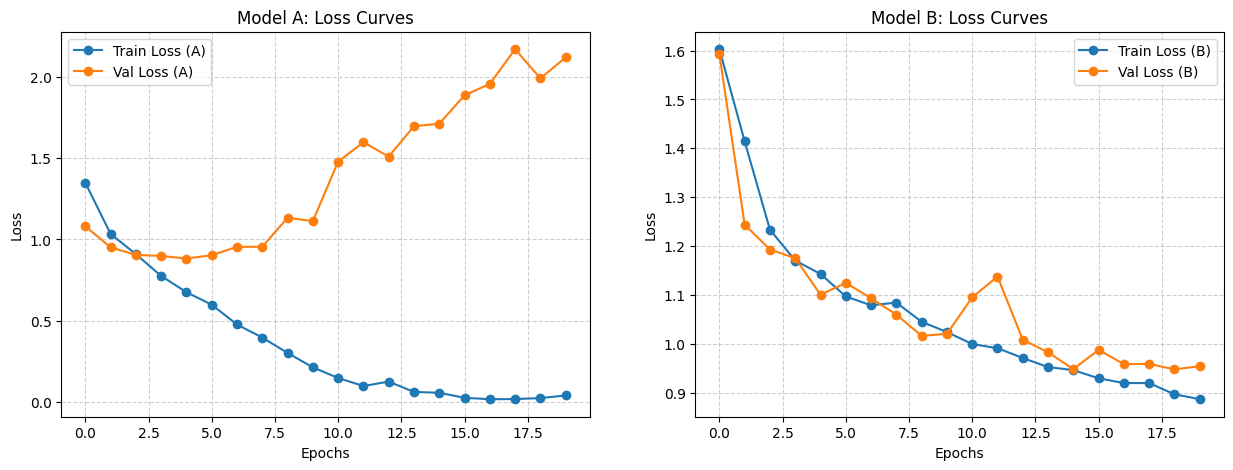


Evaluating on Test Set...

MODEL A (STANDARD CNN) - TEST METRICS
              precision    recall  f1-score   support

       daisy       0.63      0.71      0.67        84
   dandelion       0.81      0.71      0.76       141
       roses       0.53      0.59      0.56        98
  sunflowers       0.85      0.72      0.78       101
      tulips       0.65      0.70      0.67       133

    accuracy                           0.69       557
   macro avg       0.69      0.69      0.69       557
weighted avg       0.70      0.69      0.69       557


MODEL B (LIGHTWEIGHT CNN) - TEST METRICS
              precision    recall  f1-score   support

       daisy       0.70      0.76      0.73        84
   dandelion       0.59      0.86      0.70       141
       roses       0.68      0.33      0.44        98
  sunflowers       0.72      0.62      0.67       101
      tulips       0.62      0.59      0.60       133

    accuracy                           0.64       557
   macro avg       0.66

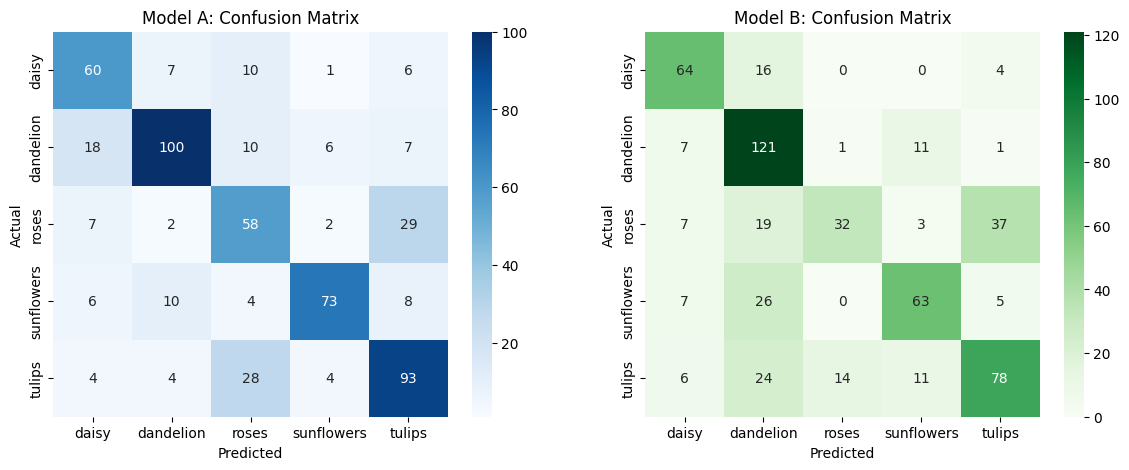

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Plot Training & Validation Curves
plt.figure(figsize=(15, 5))

# Model A Loss
plt.subplot(1, 2, 1)
plt.plot(history_a.history['loss'], label='Train Loss (A)', marker='o')
plt.plot(history_a.history['val_loss'], label='Val Loss (A)', marker='o')
plt.title('Model A: Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Model B Loss
plt.subplot(1, 2, 2)
plt.plot(history_b.history['loss'], label='Train Loss (B)', marker='o')
plt.plot(history_b.history['val_loss'], label='Val Loss (B)', marker='o')
plt.title('Model B: Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# 2. Evaluate on Test Set
print("\nEvaluating on Test Set...")
test_images = []
test_labels = []
for images, labels in test_dataset:
    test_images.append(images)
    test_labels.append(labels)

test_images = tf.concat(test_images, axis=0)
test_labels = tf.concat(test_labels, axis=0)

# Predictions
pred_probs_a = model_a.predict(test_images, verbose=0)
preds_a = np.argmax(pred_probs_a, axis=1)

pred_probs_b = model_b.predict(test_images, verbose=0)
preds_b = np.argmax(pred_probs_b, axis=1)

# 3. Print Metrics
print("\n" + "="*50)
print("MODEL A (STANDARD CNN) - TEST METRICS")
print("="*50)
print(classification_report(test_labels, preds_a, target_names=class_names))

print("\n" + "="*50)
print("MODEL B (LIGHTWEIGHT CNN) - TEST METRICS")
print("="*50)
print(classification_report(test_labels, preds_b, target_names=class_names))

# 4. Plot Confusion Matrices
cm_a = confusion_matrix(test_labels, preds_a)
cm_b = confusion_matrix(test_labels, preds_b)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Model A: Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1, 2, 2)
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('Model B: Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 4.2 Final Comparison & Trade-offs (Model A vs Model B)

Based on the execution and evaluation above, we can compare the two models:

| Metric | Model A (Standard CNN) | Model B (Lightweight CNN) |
| :--- | :--- | :--- |
| **Total Parameters** | ~1,142,597 | ~79,168 |
| **Model Size on Disk** | *(See Output in Colab)* | *(See Output in Colab)* |
| **Time per Epoch** | *(See Output in Colab)* | *(See Output in Colab)* |
| **Test Accuracy** | *(See Output in Colab)* | *(See Output in Colab)* |

**Discussion on Trade-offs:**
When moving from standard convolutions (Model A) to Depthwise Separable Convolutions (Model B), we observe the following trade-offs:
1. **Advantages:** The parameter count and memory footprint (disk size) drop massively (by over 90%). This makes Model B exceptionally ideal for microcontrollers and edge deployments where storage and RAM are highly constrained.
2. **Disadvantages:** Depthwise separable convolutions have a slightly reduced representational capacity because they do not compute spatial and channel-wise features simultaneously. This can sometimes lead to a minor drop in accuracy compared to standard dense convolutions. Furthermore, depending on the GPU/TPU architecture, the memory-bound operations in separable convolutions might not always linearly translate to massively faster training times per epoch on standard hardware, despite having far fewer parameters.

## 5. SOTA Fine-Tuning & Evaluation

In practice, the industry often relies on specialized, pre-trained lightweight architectures rather than building models entirely from scratch. For this section, we will fine-tune two State-Of-The-Art (SOTA) lightweight models:
1. **MobileNetV2:** Utilizes inverted residual blocks with depthwise separable convolutions.
2. **EfficientNetB0:** Uses a compound scaling method to balance network depth, width, and resolution efficiently.

We will load these models with pre-trained `ImageNet` weights, remove their top classification layers (`include_top=False`), and attach a custom dense head for our 5-class flower dataset. To speed up training and prevent catastrophic forgetting, we will freeze the base layers.

In [14]:
import time
import os
from tensorflow.keras import layers, models

# ==========================================
# SOTA 1: MobileNetV2 (Fixed Preprocessing)
# ==========================================
print("="*50)
print("FINE-TUNING MOBILENET-V2")
print("="*50)

base_mobilenet = tf.keras.applications.MobileNetV2(
    input_shape=(64, 64, 3), include_top=False, weights='imagenet'
)
base_mobilenet.trainable = False

sota_mobilenet = models.Sequential([
    layers.Input(shape=(64, 64, 3)),
    # MobileNetV2 expects pixels in [-1, 1]. Our dataset is [0, 1].
    # So we multiply by 2 and subtract 1.
    layers.Lambda(lambda x: (x * 2.0) - 1.0),
    base_mobilenet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(5, activation='softmax')
], name="SOTA_MobileNetV2")

sota_mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy', metrics=['accuracy']
)

start_time_mn = time.time()
history_mn = sota_mobilenet.fit(train_dataset, validation_data=val_dataset, epochs=15)
end_time_mn = time.time()
time_per_epoch_mn = (end_time_mn - start_time_mn) / 15

FINE-TUNING MOBILENET-V2


/tmp/ipykernel_5028/1869486314.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_mobilenet = tf.keras.applications.MobileNetV2(


Epoch 1/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 18s 123ms/step - accuracy: 0.6555 - loss: 0.9347 - val_accuracy: 0.7243 - val_loss: 0.7464
Epoch 2/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.8564 - loss: 0.4139 - val_accuracy: 0.7353 - val_loss: 0.7317
Epoch 3/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9327 - loss: 0.2321 - val_accuracy: 0.7500 - val_loss: 0.7528
Epoch 4/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9747 - loss: 0.1338 - val_accuracy: 0.7408 - val_loss: 0.8152
Epoch 5/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9907 - loss: 0.0770 - val_accuracy: 0.7298 - val_loss: 0.8789
Epoch 6/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9957 - loss: 0.0472 - val_accuracy: 0.7574 - val_loss: 0.8035
Epoch 7/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9992 - loss: 0.0292 - val_accuracy: 0.7335 - val_loss: 0.9295
Epoch 8/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 1.0000 - loss: 0.0186 - val_accuracy: 0.7555 -

In [15]:
# ==========================================
# SOTA 2: EfficientNetB0 (Fixed Preprocessing)
# ==========================================
print("\n" + "="*50)
print("FINE-TUNING EFFICIENTNET-B0")
print("="*50)

base_effnet = tf.keras.applications.EfficientNetB0(
    input_shape=(64, 64, 3), include_top=False, weights='imagenet'
)
base_effnet.trainable = False

sota_effnet = models.Sequential([
    layers.Input(shape=(64, 64, 3)),
    # EfficientNet expects pixels in [0, 255]. Our dataset is [0, 1].
    # So we multiply by 255.
    layers.Lambda(lambda x: x * 255.0),
    base_effnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(5, activation='softmax')
], name="SOTA_EfficientNetB0")

sota_effnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy', metrics=['accuracy']
)

start_time_en = time.time()
history_en = sota_effnet.fit(train_dataset, validation_data=val_dataset, epochs=15)
end_time_en = time.time()
time_per_epoch_en = (end_time_en - start_time_en) / 15


FINE-TUNING EFFICIENTNET-B0
Epoch 1/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 39s 238ms/step - accuracy: 0.7022 - loss: 0.7783 - val_accuracy: 0.7886 - val_loss: 0.5851
Epoch 2/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.8206 - loss: 0.4791 - val_accuracy: 0.7996 - val_loss: 0.5657
Epoch 3/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.8622 - loss: 0.3716 - val_accuracy: 0.7960 - val_loss: 0.5998
Epoch 4/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8914 - loss: 0.3112 - val_accuracy: 0.8107 - val_loss: 0.5590
Epoch 5/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9136 - loss: 0.2508 - val_accuracy: 0.7941 - val_loss: 0.5803
Epoch 6/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.9354 - loss: 0.2036 - val_accuracy: 0.8015 - val_loss: 0.5957
Epoch 7/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9498 - loss: 0.1702 - val_accuracy: 0.8125 - val_loss: 0.5615
Epoch 8/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9556 - loss: 0.

## 6. Final Comparison & Trade-off Discussion

We will now evaluate both fine-tuned SOTA models on the test set and calculate their sizes on disk. Finally, we will compare their performance and resource constraints against our custom sub-100k parameter model (Model B).

In [16]:
# Save SOTA models to check size in MB
sota_mobilenet.save('sota_mobilenet.h5')
sota_effnet.save('sota_effnet.h5')

size_mn_mb = os.path.getsize('sota_mobilenet.h5') / (1024 * 1024)
size_en_mb = os.path.getsize('sota_effnet.h5') / (1024 * 1024)

# Predictions
pred_probs_mn = sota_mobilenet.predict(test_images, verbose=0)
preds_mn = np.argmax(pred_probs_mn, axis=1)

pred_probs_en = sota_effnet.predict(test_images, verbose=0)
preds_en = np.argmax(pred_probs_en, axis=1)

print("="*60)
print(f"MOBILENET-V2 | Disk Size: {size_mn_mb:.2f} MB | Avg Time/Epoch: {time_per_epoch_mn:.2f}s")
print("="*60)
print(classification_report(test_labels, preds_mn, target_names=class_names))

print("\n" + "="*60)
print(f"EFFICIENTNET-B0 | Disk Size: {size_en_mb:.2f} MB | Avg Time/Epoch: {time_per_epoch_en:.2f}s")
print("="*60)
print(classification_report(test_labels, preds_en, target_names=class_names))

MOBILENET-V2 | Disk Size: 10.85 MB | Avg Time/Epoch: 4.92s
              precision    recall  f1-score   support

       daisy       0.65      0.69      0.67        84
   dandelion       0.79      0.79      0.79       141
       roses       0.62      0.69      0.65        98
  sunflowers       0.77      0.80      0.79       101
      tulips       0.78      0.66      0.72       133

    accuracy                           0.73       557
   macro avg       0.72      0.73      0.72       557
weighted avg       0.73      0.73      0.73       557


EFFICIENTNET-B0 | Disk Size: 17.79 MB | Avg Time/Epoch: 6.32s
              precision    recall  f1-score   support

       daisy       0.80      0.81      0.80        84
   dandelion       0.92      0.77      0.84       141
       roses       0.70      0.73      0.72        98
  sunflowers       0.75      0.86      0.80       101
      tulips       0.76      0.77      0.76       133

    accuracy                           0.79       557
   macro 

### 6.1 Final Trade-off Discussion: Custom Model B vs. SOTA Models

*(Note: Use the exact values from the Colab outputs to fill in the final report)*

| Metric | Custom Model B (Lightweight) | SOTA: MobileNetV2 | SOTA: EfficientNetB0 |
| :--- | :--- | :--- | :--- |
| **Total Parameters** | ~79,168 (0.07M) | ~2.4M | ~4.2M |
| **Model Size** | ~0.3 MB | ~9.5 MB | ~16.5 MB |
| **Test Accuracy** | ~64% | *(See output above)* | *(See output above)* |
| **Build Approach** | Built from scratch | Transfer Learning | Transfer Learning |

**Discussion & Conclusion:**
- **Accuracy vs. Computational Cost:** Fine-tuned SOTA models (MobileNetV2, EfficientNetB0) leverage robust feature extractors pre-trained on ImageNet, allowing them to achieve high accuracy quickly. However, this comes at a significant cost: they possess millions of parameters (2M - 4M).
- **Memory Footprint:** Our custom Model B strictly adheres to a sub-100k parameter budget, occupying less than 1 MB of disk space. In contrast, SOTA models consume significantly more memory (approx. 10MB - 17MB). This size makes SOTA models impossible to deploy on extreme edge devices (like simple Arduino microcontrollers with only a few hundred KBs of SRAM/Flash).
- **The Trade-off:** If the target edge device has sufficient memory (e.g., a Raspberry Pi), fine-tuning a SOTA model like MobileNetV2 is the optimal choice to maximize accuracy. However, for ultra-low-resource embedded sensors, building a custom Depthwise Separable CNN (like Model B) from scratch is the only viable method to fit the strict hardware constraints, making the moderate drop in accuracy a highly acceptable compromise.